![Cloud-First](../figures/CloudFirst.png) 


# SIT742: Modern Data Science 
**(Module: Data Science)**

---
- Materials in this module include resources collected from various open-source online repositories.
- You are free to use, change and distribute this package.
- If you found any issue/bug for this document, please submit an issue at [tulip-lab/sit742](https://github.com/tulip-lab/sit742/issues)


Prepared by **SIT742 Teaching Team**

---


## Session 3E: Data Acquisition (2)

In this session, we will learn how to use Python Packages to ETL the data and files.



### Content


1. `Pandas` Basics

2. Loading `CSV` Data

3. Data Extraction through Web `API` 

4. Web Crawling using `BeautifulSoup`



**Note**: The data available on those service might be changing, so you need to adjust the code to accommodate those changes.

---

## Part 1. `Pandas` Basics


`Pandas` is an open source, BSD-licensed library providing high-performance, easy-to-use data structures and data analysis tools for the Python programming language.

To get started, we can import `Pandas` with:

In [1]:
import pandas as pd


#### `Series` and `DataFrame`

Two core components of pandas are the `Series` and `DataFrame`. A `Series` is essentially a column, and a `DataFrame` is a multi-dimensional table made up of a collection of `series`. For a two dimensional DataFrame, the row labels are referred to as `index`, and the column labels are referred to as `columns`.

There are many ways to create a dataframe, and one common option is to use a simple dictionary with each entry acting as a column in the dataframe, as shown in below:



In [4]:
# Defining DataFrame by specifing a list of observations
df_1= pd.DataFrame([['a', 'b', 'c'],
                 ['d', 'e', 'f'],
                 ['g', 'h', 'i']],
                index = [1,2,3], columns = ['col1', 'col2', 'col3'])
                
# Defining DataFrame by specifing a dictionary of columns 
df_2= pd.DataFrame({'col1': ['a', 'd', 'g'], 
                 'col2': ['b', 'e', 'h'],
                 'col3': ['c', 'f', 'i']}, 
                 index = [1,2,3])


Both `df_1` and `df_2` defined above are identical.

The index labels, columns labels, and data values stored in the dataframe `df_1` can be retrieved using `df_1.index`, `df_1.columns` and `df_1.values` respectively.


In [5]:
df_1.index
df_1.columns
df_1.values


array([['a', 'b', 'c'],
       ['d', 'e', 'f'],
       ['g', 'h', 'i']], dtype=object)

`Pandas` also provides operations to inspect a dataframe to gain better understanding of its contents.

- `.head(n)` and `.tail(n)` returns the top and bottom `n` rows of the dataframe, respectively.
- `.describe()` returns summary of all numerical variables (columns) in the dataset.



In [6]:
df_1.head(2)
df_1.tail(2)
df_1.describe()


,col1,col2,col3
count,3,3,3
unique,3,3,3
top,a,b,c
freq,1,1,1


## Part 2. Loading `CSV` Data

Here you will learn  how to use Pandas 
[read_csv()](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html) function to load a CSV file. Before we start importing our CSV file, it might be good for you to read [Pandas tutorial on reading CSV files](http://pandas.pydata.org/pandas-docs/stable/io.html#io-read-csv-table).

If `wget` was not installed in your `Python` platform, install it first:


In [7]:
!pip install wget


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9657 sha256=8d44886c6c971df317f63e15b9ee0e2452bf091fd2385e7d4a1013c4b4629f31
  Stored in directory: /root/.cache/pip/wheels/8b/f1/7f/5c94f0a7a505ca1c81cd1d9208ae2064675d97582078e6c769
Successfully built wget


Suppose the `csv` data file is avilable at a URL, we use `wget` to download it to the local file system.


In [8]:
import wget

link_to_data = 'https://github.com/tulip-lab/sit742/raw/master/Jupyter/data/Melbourne_bike_share.csv'

DataSet = wget.download(link_to_data)


### Importing `CSV` data

Importing `CSV` files with `Pandas` function [`read_csv()`](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html)  and converting the data into a form Python can understand is simple. It only takes a couple of lines of code. The imported data will be stored in Pandas `DataFrame`.



In [9]:
import pandas as pd
csvdf = pd.read_csv("Melbourne_bike_share.csv")
type(csvdf)

pandas.core.frame.DataFrame

### Inspecting the Data

Now, the data should be loaded into `Python`.  Let's have a look at the first 5 records in the dataset. There are a coupe of ways to retrieve these records.

For example, you can use 
* `csvdf.head(n = 5)`: It will return first `n` rows in a DataFrame, `n = 5` by default.
* `csvdf[:5]`: It uses the slicing method to retrieve the first `5` rows.

Refer to "[Indexing and Selecting Data](http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html)"
for how to slice, dice, and generally get and set subsets of pandas objects.

Here, we use the `head` function.

In [47]:
# have an oveall inspection
csvdf.describe()

#We can use the head instead of the For Statement shown in the above example.
csvdf.head()
csvdf[:5]
csvdf.loc[:4] 

#tail is used to show last several records.
csvdf.tail()

,Featurename,TerminalName,NBBikes,NBEmptydoc,UploadDate,Coordinates
ID,,,,,,
51,ANZ - Collins St - Docklands,60044,9,10,28/01/2016 12:30:06 PM +0000,"(-37.821568, 144.944488)"
52,Flagstaff Gardens - Peel St - West Melbourne,60048,6,5,28/01/2016 12:30:06 PM +0000,"(-37.809216, 144.955223)"
53,Victoria Market - Elizabeth St / Victoria St -...,60049,15,10,28/01/2016 12:30:06 PM +0000,"(-37.806091, 144.959017)"
55,Coventry St / Clarendon St - South Melbourne,60050,7,4,28/01/2016 12:30:06 PM +0000,"(-37.831776, 144.960818)"
57,Fitzroy Street - St Kilda,60052,19,12,28/01/2016 12:30:06 PM +0000,"(-37.858655, 144.978818)"


Currently, the row indices are integers automatically generated by `Pandas`.
Suppose you want to set IDs as row indices and delete the ID column.
Resetting the row indices can be easily done with the following DataFrame function：

>DataFrame.set_index(keys, drop=True, append=False, inplace=False, verify_integrity=False)


See its [API webpage](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.set_index.html) 
for the detailed usage.
The keys are going to be the IDs in the first column. 
By setting `inplace = True`, the corresponding change is done inplace and won't return a new DataFrame object.


In [11]:
#To show how many records in the file
len(csvdf.ID.unique())

csvdf.set_index(csvdf.ID, inplace = True)
csvdf.head()

,ID,Featurename,TerminalName,NBBikes,NBEmptydoc,UploadDate,Coordinates
ID,,,,,,,
2,2,Harbour Town - Docklands Dve - Docklands,60000,9,14,28/01/2016 12:30:05 PM +0000,"(-37.814022, 144.939521)"
4,4,Federation Square - Flinders St / Swanston St ...,60001,12,10,28/01/2016 12:30:05 PM +0000,"(-37.817523, 144.967814)"
5,5,Plum Garland Reserve - Beaconsfield Pde - Albe...,60002,16,1,28/01/2016 12:30:05 PM +0000,"(-37.84782, 144.948196)"
6,6,State Library - Swanston St / Little Lonsdale ...,60003,9,2,28/01/2016 12:30:05 PM +0000,"(-37.810702, 144.964417)"
7,7,Bourke Street Mall - 205 Bourke St - City,60004,9,2,28/01/2016 12:30:05 PM +0000,"(-37.813088, 144.967437)"


To remove the ID column that is now redundant, you use DataFrame `drop` function and set `inplace = True`
>DataFrame.drop(labels, axis=0, level=None, inplace=False, errors='raise')

In [12]:
csvdf.drop('ID', 1, inplace = True)
csvdf.head()

<ipython-input-12-f17353b73d2a>:1: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  csvdf.drop('ID', 1, inplace = True)


,Featurename,TerminalName,NBBikes,NBEmptydoc,UploadDate,Coordinates
ID,,,,,,
2,Harbour Town - Docklands Dve - Docklands,60000,9,14,28/01/2016 12:30:05 PM +0000,"(-37.814022, 144.939521)"
4,Federation Square - Flinders St / Swanston St ...,60001,12,10,28/01/2016 12:30:05 PM +0000,"(-37.817523, 144.967814)"
5,Plum Garland Reserve - Beaconsfield Pde - Albe...,60002,16,1,28/01/2016 12:30:05 PM +0000,"(-37.84782, 144.948196)"
6,State Library - Swanston St / Little Lonsdale ...,60003,9,2,28/01/2016 12:30:05 PM +0000,"(-37.810702, 144.964417)"
7,Bourke Street Mall - 205 Bourke St - City,60004,9,2,28/01/2016 12:30:05 PM +0000,"(-37.813088, 144.967437)"


## Part 3. Data Extraction through Web `API` 


Many of you will probably be interested in scraping data from the web for your projects. For example, what if we were interested in working with some historical Canadian weather data? Well, we can get that from: http://climate.weather.gc.ca using their API. Requests are going to be formatted like this:


In [13]:
import pandas as pd

url_template = "http://climate.weather.gc.ca/climate_data/bulk_data_e.html?format=csv&stationID=5415&Year={year}&Month={month}&timeframe=1&submit=Download+Data"

Note that we've requested the data be returned as a CSV, and that we're going to supply the month and year as inputs when we fire off the query. To get the data for March 2012, we need to format it with month=3, year=2012:


In [14]:
url = url_template.format(month=3, year=2012)
url

'http://climate.weather.gc.ca/climate_data/bulk_data_e.html?format=csv&stationID=5415&Year=2012&Month=3&timeframe=1&submit=Download+Data'

This is great! We can just use the same `read_csv` function as before, and just give it a URL as a filename. Awesome.

Upon inspection, we find out that there are 0 rows (as in 03/2020) of metadata at the top of this CSV, but pandas knows CSVs are weird, so there's a `skiprows` options. We parse the dates again, and set 'Date/Time' to be the index column. Here's the resulting dataframe.

In [15]:
weather_mar2012 = pd.read_csv(url, skiprows=0, index_col='Date/Time (LST)', parse_dates=True, encoding='latin1')

In [16]:
weather_mar2012.head()

,"ï»¿""Longitude (x)""",Latitude (y),Station Name,Climate ID,Year,Month,Day,Time (LST),Temp (Â°C),Temp Flag,...,Wind Spd Flag,Visibility (km),Visibility Flag,Stn Press (kPa),Stn Press Flag,Hmdx,Hmdx Flag,Wind Chill,Wind Chill Flag,Weather
Date/Time (LST),,,,,,,,,,,,,,,,,,,,,
2012-03-01 00:00:00,-73.75,45.47,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL A,7025250,2012,3,1,00:00,-5.5,NaN,...,NaN,4.0,NaN,100.97,NaN,NaN,NaN,-13.0,NaN,Snow
2012-03-01 01:00:00,-73.75,45.47,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL A,7025250,2012,3,1,01:00,-5.7,NaN,...,NaN,2.4,NaN,100.87,NaN,NaN,NaN,-13.0,NaN,Snow
2012-03-01 02:00:00,-73.75,45.47,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL A,7025250,2012,3,1,02:00,-5.4,NaN,...,NaN,4.8,NaN,100.80,NaN,NaN,NaN,-13.0,NaN,Snow
2012-03-01 03:00:00,-73.75,45.47,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL A,7025250,2012,3,1,03:00,-4.7,NaN,...,NaN,4.0,NaN,100.69,NaN,NaN,NaN,-12.0,NaN,Snow
2012-03-01 04:00:00,-73.75,45.47,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL A,7025250,2012,3,1,04:00,-5.4,NaN,...,NaN,1.6,NaN,100.62,NaN,NaN,NaN,-14.0,NaN,Snow


As before, we can get rid of any columns that don't contain real data using ${\tt .dropna()}$

In [17]:
weather_mar2012 = weather_mar2012.dropna(axis=1, how='any')

In [18]:
weather_mar2012.head()

,"ï»¿""Longitude (x)""",Latitude (y),Station Name,Climate ID,Year,Month,Day,Time (LST),Temp (Â°C),Dew Point Temp (Â°C),Rel Hum (%),Wind Spd (km/h),Visibility (km),Stn Press (kPa),Weather
Date/Time (LST),,,,,,,,,,,,,,,
2012-03-01 00:00:00,-73.75,45.47,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL A,7025250,2012,3,1,00:00,-5.5,-9.7,72,24,4.0,100.97,Snow
2012-03-01 01:00:00,-73.75,45.47,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL A,7025250,2012,3,1,01:00,-5.7,-8.7,79,26,2.4,100.87,Snow
2012-03-01 02:00:00,-73.75,45.47,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL A,7025250,2012,3,1,02:00,-5.4,-8.3,80,28,4.8,100.80,Snow
2012-03-01 03:00:00,-73.75,45.47,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL A,7025250,2012,3,1,03:00,-4.7,-7.7,79,28,4.0,100.69,Snow
2012-03-01 04:00:00,-73.75,45.47,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL A,7025250,2012,3,1,04:00,-5.4,-7.8,83,35,1.6,100.62,Snow


Getting better! The Year/Month/Day/Time columns are redundant, though, and the Data Quality column doesn't look too useful. Let's get rid of those.

In [19]:
weather_mar2012 = weather_mar2012.drop(['Year', 'Month', 'Day', 'Time (LST)'], axis=1)
weather_mar2012[:5]

,"ï»¿""Longitude (x)""",Latitude (y),Station Name,Climate ID,Temp (Â°C),Dew Point Temp (Â°C),Rel Hum (%),Wind Spd (km/h),Visibility (km),Stn Press (kPa),Weather
Date/Time (LST),,,,,,,,,,,
2012-03-01 00:00:00,-73.75,45.47,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL A,7025250,-5.5,-9.7,72,24,4.0,100.97,Snow
2012-03-01 01:00:00,-73.75,45.47,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL A,7025250,-5.7,-8.7,79,26,2.4,100.87,Snow
2012-03-01 02:00:00,-73.75,45.47,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL A,7025250,-5.4,-8.3,80,28,4.8,100.80,Snow
2012-03-01 03:00:00,-73.75,45.47,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL A,7025250,-4.7,-7.7,79,28,4.0,100.69,Snow
2012-03-01 04:00:00,-73.75,45.47,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL A,7025250,-5.4,-7.8,83,35,1.6,100.62,Snow


Great! Now let's figure out how to download the whole year? It would be nice if we could just send that as a single request, but like many APIs this one is limited to prevent people from hogging bandwidth. No problem: we can write a function!

In [20]:
def download_weather_month(year, month):
    url = url_template.format(year=year, month=month)
    weather_data = pd.read_csv(url, skiprows=0, index_col='Date/Time (LST)', parse_dates=True)
    weather_data = weather_data.dropna(axis=1)
    weather_data.columns = [col.replace('\xb0', '') for col in weather_data.columns]
    weather_data = weather_data.drop(['Year', 'Day', 'Month', 'Time (LST)'], axis=1)
    return weather_data

Now to test that this function does the right thing:

In [21]:
download_weather_month(2020, 1).head()

,Longitude (x),Latitude (y),Station Name,Climate ID
Date/Time (LST),,,,
2020-01-01 00:00:00,-73.75,45.47,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL A,7025250
2020-01-01 01:00:00,-73.75,45.47,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL A,7025250
2020-01-01 02:00:00,-73.75,45.47,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL A,7025250
2020-01-01 03:00:00,-73.75,45.47,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL A,7025250
2020-01-01 04:00:00,-73.75,45.47,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL A,7025250


Woohoo! Now we can iteratively request all the months using a single line. This will take a little while to run.

In [22]:
data_by_month = [download_weather_month(2012, i) for i in range(1, 12)]

Once that's done, it's easy to concatenate all the dataframes together into one big dataframe using ${\tt pandas.concat()}$. And now we have the whole year's data!

In [23]:
weather_2012 = pd.concat(data_by_month)

This thing is long, so instead of printing out the whole thing, I'm just going to print a quick summary of the ${\tt DataFrame}$ by calling ${\tt .info()}$:

In [24]:
weather_2012.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8040 entries, 2012-01-01 00:00:00 to 2012-11-30 23:00:00
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Longitude (x)       8040 non-null   float64
 1   Latitude (y)        8040 non-null   float64
 2   Station Name        8040 non-null   object 
 3   Climate ID          8040 non-null   int64  
 4   Temp (C)            8040 non-null   float64
 5   Dew Point Temp (C)  8040 non-null   float64
 6   Rel Hum (%)         8040 non-null   int64  
 7   Wind Spd (km/h)     8040 non-null   int64  
 8   Visibility (km)     8040 non-null   float64
 9   Stn Press (kPa)     8040 non-null   float64
 10  Weather             8040 non-null   object 
dtypes: float64(6), int64(3), object(2)
memory usage: 753.8+ KB


And a quick reminder, if we wanted to save that data to a file:

In [25]:
weather_2012.to_csv('weather_2012.csv')

In [26]:
!ls

Melbourne_bike_share.csv  sample_data  weather_2012.csv


And finally, something you should do early on in the wrangling process, plot data:

Text(0, 0.5, 'Temperature')

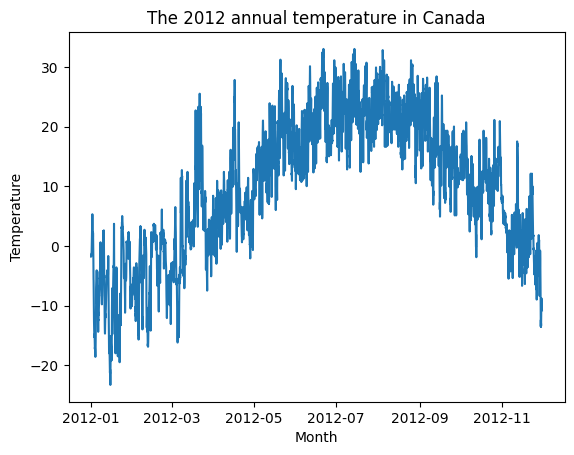

In [27]:
# plot that data
import matplotlib.pyplot as plt 
# so now 'plt' means matplotlib.pyplot
dateRange = weather_2012.index
temperature = weather_2012['Temp (C)']

df1 = pd.DataFrame({'Temperature' : temperature}, index=dateRange)
      
plt.plot(df1.index.to_pydatetime(), df1.Temperature)
plt.title("The 2012 annual temperature in Canada")
plt.xlabel("Month")
plt.ylabel("Temperature")

In [28]:
# nothing to see... in iPython you need to specify where the chart will display, usually it's in a new window
# to see them 'inline' use:
%matplotlib inline
#If you add the %matplotlib inline, then you can skip the plt.show() function.
#How to close python warnings
import warnings
warnings.filterwarnings('ignore')

<Axes: xlabel='Temp (C)', ylabel='Wind Spd (km/h)'>

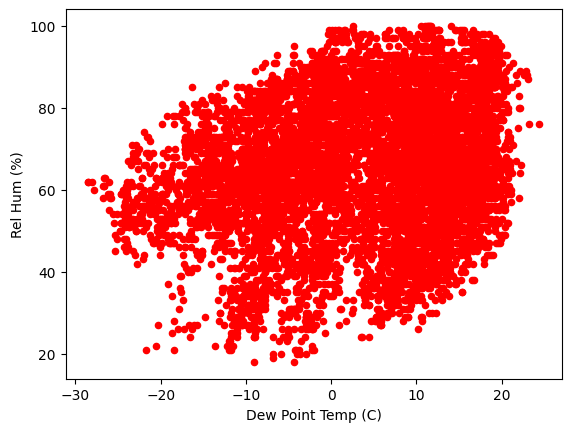

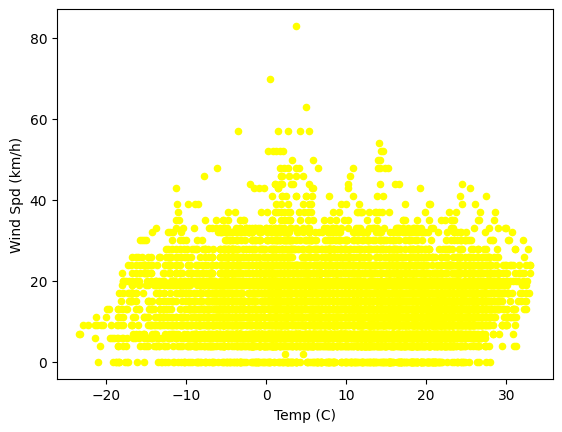

In [29]:
# that's better, try other plots, scatter is popular, also boxplott
df1 = pd.read_csv('weather_2012.csv', low_memory=False)
df1.plot(kind='scatter',x='Dew Point Temp (C)',y='Rel Hum (%)',color='red')
df1.plot(kind='scatter',x='Temp (C)',y='Wind Spd (km/h)',color='yellow')

In [30]:
# show first several 'weather' columns value
weather_2012['Weather'].head()

Date/Time (LST)
2012-01-01 00:00:00                     Fog
2012-01-01 01:00:00                     Fog
2012-01-01 02:00:00    Freezing Drizzle,Fog
2012-01-01 03:00:00    Freezing Drizzle,Fog
2012-01-01 04:00:00                     Fog
Name: Weather, dtype: object

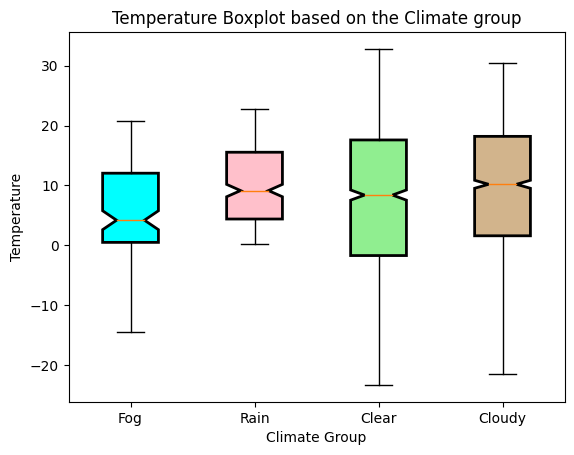

In [31]:

#Boxplot sample
climategroup1 = df1[df1['Weather']=='Fog']['Temp (C)']
climategroup2 = df1[df1['Weather']=='Rain']['Temp (C)']
climategroup3 = df1[df1['Weather']=='Clear']['Temp (C)']
climategroup4 = df1[df1['Weather']=='Cloudy']['Temp (C)']

data =[climategroup1,climategroup2,climategroup3,climategroup4]


fig1, ax1 = plt.subplots()
ax1.set_title('Temperature Boxplot based on the Climate group')
ax1.set_ylabel('Temperature')
ax1.set_xlabel('Climate Group')

boxplot=ax1.boxplot(data, 
                    notch=True,
                    patch_artist=True,
                    labels=['Fog','Rain','Clear','Cloudy'],
                    boxprops=dict(linestyle='--', linewidth=2, color='black'))

colors = ['cyan', 'pink', 'lightgreen', 'tan', 'pink']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

## Part 4. States and Territories of Australia 

We are interested in getting  State and Territory information from Wikipedia, however we do not want to copy and paste the table : )

Here is the URL
https://en.wikipedia.org/wiki/States_and_territories_of_Australia   

We need two libraries to do the task:

Check documentations here:
* [urllib](https://docs.python.org/2/library/urllib.html)
* [BeautifulSoup](https://www.crummy.com/software/BeautifulSoup/bs4/doc/)


In [32]:
import sys
if sys.version_info[0] == 3:
    from urllib.request import urlopen
else:
    from urllib import urlopen
from bs4 import BeautifulSoup

We first save the link in wiki

In [33]:
wiki = "https://en.wikipedia.org/wiki/States_and_territories_of_Australia"

Then use ulropen to open the page. 

If you get "SSL: CERTIFICATE_VERIFY_FAILED", what you need to do is find where "Install Certificates.command" file is, and click it to upgrade the certificate. Then, you should be able to solve the problem.

In [34]:
page = urlopen(wiki)

In [35]:
if sys.version_info[0] == 3:
    page = page.read()

You will meet BeautifulSoup later in this subject, so don't worry if you feel uncomfortable with it now. You can always revisit. 

We begin by reading in the source code and creating a Beautiful Soup object with the BeautifulSoup function.

In [36]:
soup = BeautifulSoup(page, "lxml")

Then we print and see. 

In [37]:
print(soup.prettify())

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-sticky-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-enabled vector-feature-main-menu-pinned-disabled vector-feature-limited-width-enabled vector-feature-limited-width-content-enabled vector-feature-zebra-design-disabled" dir="ltr" lang="en">
 <head>
  <meta charset="utf-8"/>
  <title>
   States and territories of Australia - Wikipedia
  </title>
  <script>
   document.documentElement.className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-sticky-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-enabled vector-feature-main-menu-pinned-disabled vector-feature-limited-width-enabled vector-feature-limited-width-content-enabled vector-feature-zebra-design-disabled";(function(){var cookie=document.

For who do not know much about HTML, this might be a bit overwhelming, but essentially it contains lots of tags in the angled brackets providing structural and formatting information that we don't care so much here. What we need is the table. 

Let's first check the title.

In [38]:
soup.title.string

'States and territories of Australia - Wikipedia'

It looks fine, then we would like to find the table. 

Let's have a try to extract all contents within the 'table' tag.

In [39]:
all_tables = soup.findAll('table')
print(all_tables)

[<table class="box-More_citations_needed plainlinks metadata ambox ambox-content ambox-Refimprove" role="presentation"><tbody><tr><td class="mbox-image"><div class="mbox-image-div"><a class="image" href="/wiki/File:Question_book-new.svg"><img alt="" data-file-height="399" data-file-width="512" decoding="async" height="39" src="//upload.wikimedia.org/wikipedia/en/thumb/9/99/Question_book-new.svg/50px-Question_book-new.svg.png" srcset="//upload.wikimedia.org/wikipedia/en/thumb/9/99/Question_book-new.svg/75px-Question_book-new.svg.png 1.5x, //upload.wikimedia.org/wikipedia/en/thumb/9/99/Question_book-new.svg/100px-Question_book-new.svg.png 2x" width="50"/></a></div></td><td class="mbox-text"><div class="mbox-text-span">This article <b>needs additional citations for <a href="/wiki/Wikipedia:Verifiability" title="Wikipedia:Verifiability">verification</a></b>.<span class="hide-when-compact"> Please help <a class="external text" href="https://en.wikipedia.org/w/index.php?title=States_and_terr

This returns a collection of tag objects. It seems that most of the information are useless and it's getting hard to hunt for the table. So searched online and found an instruction here: 

https://adesquared.wordpress.com/2013/06/16/using-python-beautifulsoup-to-scrape-a-wikipedia-table/

The class is "wikitable sortable"!! Have a try then.

In [40]:
right_table = soup.find('table', class_='wikitable sortable')
print(right_table)

<table class="wikitable sortable" style="text-align:center">
<caption style="text-align:center;background:#BFD7FF">States of Australia<sup class="reference" id="cite_ref-6"><a href="#cite_note-6">[b]</a></sup>
</caption>
<tbody><tr>
<th class="unsortable"><a href="/wiki/List_of_Australian_flags#States_and_territories" title="List of Australian flags">Flag</a>
</th>
<th scope="col" width="110">State
</th>
<th scope="col" width="030">Postal
</th>
<th scope="col" width="030"><a href="/wiki/ISO_3166-2:AU" title="ISO 3166-2:AU">ISO</a><sup class="reference" id="cite_ref-ReferenceA_7-0"><a href="#cite_note-ReferenceA-7">[5]</a></sup>
</th>
<th><a href="/wiki/List_of_Australian_capital_cities" title="List of Australian capital cities">Capital</a>
</th>
<th>Population<br/>(Sept 2022)<sup class="reference" id="cite_ref-ABSQPOP_8-0"><a href="#cite_note-ABSQPOP-8">[6]</a></sup>
</th>
<th>Area (km<sup>2</sup>)<sup class="reference" id="cite_ref-GAarea_9-0"><a href="#cite_note-GAarea-9">[7]</a></su

Next we need to extract table header row by find the first 'tr'

In [41]:
head_row = right_table.find('tr')
print(head_row)

<tr>
<th class="unsortable"><a href="/wiki/List_of_Australian_flags#States_and_territories" title="List of Australian flags">Flag</a>
</th>
<th scope="col" width="110">State
</th>
<th scope="col" width="030">Postal
</th>
<th scope="col" width="030"><a href="/wiki/ISO_3166-2:AU" title="ISO 3166-2:AU">ISO</a><sup class="reference" id="cite_ref-ReferenceA_7-0"><a href="#cite_note-ReferenceA-7">[5]</a></sup>
</th>
<th><a href="/wiki/List_of_Australian_capital_cities" title="List of Australian capital cities">Capital</a>
</th>
<th>Population<br/>(Sept 2022)<sup class="reference" id="cite_ref-ABSQPOP_8-0"><a href="#cite_note-ABSQPOP-8">[6]</a></sup>
</th>
<th>Area (km<sup>2</sup>)<sup class="reference" id="cite_ref-GAarea_9-0"><a href="#cite_note-GAarea-9">[7]</a></sup>
</th>
<th>Population Density (/km<sup>2</sup>)
</th>
<th>No. of Reps. in <a href="/wiki/Australian_House_of_Representatives" title="Australian House of Representatives">Aus House</a><sup class="reference" id="cite_ref-Commonw

Then we extract header row name via iterate through each row and extract text. 

The `.findAll` function in Python returns a list containing all the elements, which you can iterate through.

In [42]:
header_list = []
headers = head_row.findAll('th')
for header in headers:
    #print header.find(text = True)
    header_list.append(header.find(text = True).strip())
header_list

['Flag',
 'State',
 'Postal',
 'ISO',
 'Capital',
 'Population',
 'Area (km',
 'Population Density (/km',
 'No. of Reps. in',
 'Governor',
 'Premier',
 'State Government']

We can probably iterate through this list and then extract contents. But let's take a simple approach of extracting each column separately.

In [43]:
flag = []
state = []
abbrev = []
ISO = []
Capital = []
Population = []
Area = []
Seats = []
Gov = []
Premier = []

for row in right_table.findAll("tr"):
    cells = row.findAll('td')
    if len(cells) > 0 : # and len(cells) < 10:
        flag.append(cells[0].find(text=True))
        state.append(cells[1].find(text=True).strip())
        abbrev.append(cells[2].find(text=True).strip())
        ISO.append(cells[3].find(text=True).strip())
        Capital.append(cells[4].find(text=True).strip())
        Population.append(cells[5].find(text=True).strip())
        Area.append(cells[6].find(text=True).strip())
        Seats.append(cells[7].find(text=True).strip())
        Gov.append(cells[8].find(text=True).strip())
        Premier.append(cells[10].find(text=True).strip())


Next we can append all list to the dataframe.

In [44]:
df_au = pd.DataFrame()
df_au[header_list[0]] = flag
df_au[header_list[1]] = state
df_au[header_list[2]] = abbrev
df_au[header_list[3]] = ISO
df_au[header_list[4]] = Capital
df_au[header_list[5]] = Population
df_au[header_list[6]] = Area
df_au[header_list[7]] = Seats
df_au[header_list[8]] = Gov
df_au[header_list[9]] = Premier

Done !

In [45]:
df_au

,Flag,State,Postal,ISO,Capital,Population,Area (km,Population Density (/km,No. of Reps. in,Governor
0,None,New South Wales,NSW,AU-NSW,Sydney,"8,193,549","809,952",9.99,47,
1,None,Victoria,VIC,AU-VIC,Melbourne,"6,656,281","237,657",27,38,
2,None,Queensland,QLD,AU-QLD,Brisbane,"5,354,801","1,851,736",2.84,30,
3,None,Western Australia,WA,AU-WA,Perth,"2,805,019","2,642,753",1.05,16,
4,None,South Australia,SA,AU-SA,Adelaide,"1,828,701","1,044,353",1.73,10,
5,None,Tasmania,TAS,AU-TAS,Hobart,"571,873","90,758",6.28,5,
